题目描述：
已知一个两层前馈神经网络（全连接），结构如下：
输入层：3 个神经元
隐藏层：4 个神经元，激活函数为 Tanh，训练时加 Dropout，p=0.5
输出层：2 个神经元（对应二分类），无激活（CrossEntropyLoss 自动加 softmax）
参数初始化（均需 requires_grad=True）：

W1 = [[0.1, -0.2, 0.3], [0.2, 0.0, -0.1], [-0.1, 0.2, 0.1], [0.2, -0.1, 0.2]] # shape = [4, 3]

b1 = [0.0, 0.1, -0.1, 0.2] # shape = [4]

W2 = [[0.2, -0.1, 0.1, 0.3], [-0.2, 0.2, 0.2, -0.1]] # shape = [2, 4]

b2 = [0.05, -0.05] # shape = [2]

输入特征与标签：
X = [[1.0, -2.0, 0.5]] # shape = [1, 3]

y = 0 # 类别0

计算要求：
前向传播
计算隐藏层输出 H = Tanh(X @ W1^T + b1)
对 H 应用 Dropout（p=0.5，训练模式，注意推理时不加 Dropout）
计算输出层 Z = H @ W2^T + b2
用 nn.CrossEntropyLoss() 计算损失
反向传播
loss.backward()，获得各参数的梯度
参数更新
用学习率 lr=0.05，手动SGD更新一次参数（不使用优化器）
输出结果
打印 softmax 后的输出概率
打印损失值
打印每个参数的梯度
打印更新后的参数值

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available else "cpu")

In [ ]:
def forward(w1, w2, b1, b2, x):
  z1 = x @ w1.T +b1
  h = torch.tanh(z1)
  h = torch.dropout(h, p=0.5, train=True)

  z2 = h @ w2.T +b2
  return z2

epoch: 1 loss: 0.6669
epoch: 101 loss: 0.2344
epoch: 201 loss: 0.0580
epoch: 301 loss: 0.0423
epoch: 401 loss: 0.0060
epoch: 501 loss: 0.0001
epoch: 601 loss: 0.0017
epoch: 701 loss: 0.0108
epoch: 801 loss: 0.0012
epoch: 901 loss: 0.0691
epoch: 1001 loss: 0.0002
epoch: 1101 loss: 0.0012
epoch: 1201 loss: 0.0064
epoch: 1301 loss: 0.0072
epoch: 1401 loss: 0.0522
epoch: 1501 loss: 0.0496
epoch: 1601 loss: 0.0001
epoch: 1701 loss: 0.0063
epoch: 1801 loss: 0.0043
epoch: 1901 loss: 0.0040
the y_pred index value:
tensor(0, device='cuda:0')
the y_true index value:
tensor([0], device='cuda:0')


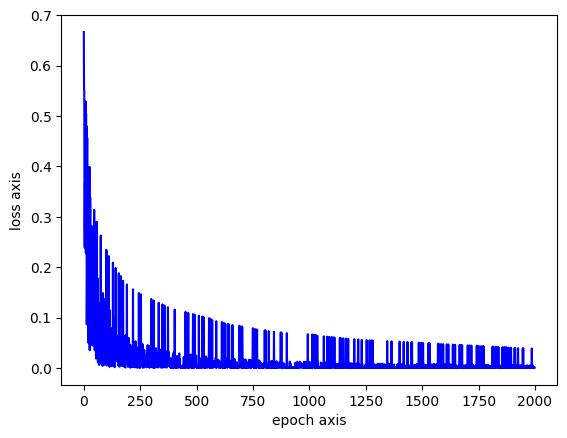

In [10]:
#初始化
w1 = torch.tensor([[0.1, -0.2, 0.3], [0.2, 0.0, -0.1], [-0.1, 0.2, 0.1], [0.2, -0.1, 0.2]]).to(device).requires_grad_() # shape = [4, 3]
b1 = torch.tensor([0.0, 0.1, -0.1, 0.2]).to(device).requires_grad_() # shape = [4]
w2 = torch.tensor([[0.2, -0.1, 0.1, 0.3], [-0.2, 0.2, 0.2, -0.1]]).to(device).requires_grad_() # shape = [2, 4]
b2 = torch.tensor([0.05, -0.05]).to(device).requires_grad_() # shape = [2]

x = torch.tensor([[1.0, -2.0, 0.5]], requires_grad=True).to(device)
y_true_index = torch.tensor([0]).to(device)

losses = []
epochs = 2000

lr = 0.05

criterion = nn.CrossEntropyLoss().to(device)

for epoch in range(epochs):
  z2 = forward(w1, w2, b1, b2, x).to(device)
  y_pred = torch.softmax(z2, dim=1).to(device)

  loss = criterion(z2, y_true_index).to(device)
  losses.append(loss.item())

  loss.backward()

  with torch.no_grad():
    w1 -= lr * w1.grad
    w2 -= lr * w2.grad
    b1 -= lr * b1.grad
    b2 -= lr * b2.grad

  w1.grad.zero_()
  w2.grad.zero_()
  b1.grad.zero_()
  b2.grad.zero_()

  if epoch % 100 ==0:
    print(f"epoch: {epoch+1}",
       f"loss: {loss.item():.4f}")

with torch.no_grad():
  y_pred_index = torch.argmax(y_pred)

print("the y_pred index value:")
print(y_pred_index)

print("the y_true index value:")
print(y_true_index)

plt.plot(range(epochs), losses, "blue")
plt.xlabel("epoch axis")
plt.ylabel("loss axis")
plt.show()